In [209]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [210]:
df = pd.read_csv('csv/bank_fraud.csv')

In [211]:
# How data looks 
df.head()

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
0,TXN0000000001,CUST00121959,2023-08-17,21:13:00,21,0,0,USA,London,Grocery,...,39.49,157,23,52.7,10.20,0,0,0,0,NaN
1,TXN0000000002,CUST00146868,2024-02-06,05:16:00,5,0,1,UK,New York,Healthcare,...,153.71,153,23,0.9,12.47,0,0,0,0,NaN
2,TXN0000000003,CUST00131933,2024-06-28,12:15:00,12,0,0,Canada,Delhi,Grocery,...,118.20,161,20,9.2,0.08,0,1,0,0,NaN
3,TXN0000000004,CUST00103695,2023-03-16,02:53:00,2,0,1,France,Tokyo,Utilities,...,49.50,160,25,14.8,17.94,1,0,1,1,Synthetic Identity
4,TXN0000000005,CUST00119880,2024-07-12,12:39:00,12,0,0,Canada,Melbourne,Clothing,...,30.74,134,18,38.9,2.16,0,0,0,0,NaN


In [212]:
df_copy = df.copy()

In [213]:
# check data info 
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 26 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   transaction_id            1000000 non-null  object 
 1   customer_id               1000000 non-null  object 
 2   transaction_date          1000000 non-null  object 
 3   transaction_time          1000000 non-null  object 
 4   hour_of_day               1000000 non-null  int64  
 5   is_weekend                1000000 non-null  int64  
 6   is_night_transaction      1000000 non-null  int64  
 7   country                   1000000 non-null  object 
 8   city                      1000000 non-null  object 
 9   merchant_category         1000000 non-null  object 
 10  payment_method            1000000 non-null  object 
 11  device_type               1000000 non-null  object 
 12  customer_age              1000000 non-null  int64  
 13  credit_score              10

In [214]:
#  get good insight using describe 
df_copy.describe()

,hour_of_day,is_weekend,is_night_transaction,customer_age,credit_score,account_age_years,account_balance,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.00000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,11.496978,0.286022,0.375057,41.771678,679.028781,4.987911,16594.25442,204.724665,149.996350,19.999322,20.009890,12.000945,0.149994,0.380072,0.080439,0.055255
std,6.923751,0.451900,0.484138,13.424588,78.828748,4.925949,28171.46068,459.567802,12.244379,4.474045,20.011427,11.999904,0.357066,0.914603,0.271972,0.228477
min,0.000000,0.000000,0.000000,18.000000,300.000000,0.100000,100.00000,1.000000,96.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,0.000000,0.000000,32.000000,625.000000,1.400000,3609.01750,33.400000,142.000000,17.000000,5.800000,3.450000,0.000000,0.000000,0.000000,0.000000
50%,11.000000,0.000000,0.000000,42.000000,680.000000,3.500000,8092.12000,73.120000,150.000000,20.000000,13.900000,8.320000,0.000000,0.000000,0.000000,0.000000
75%,18.000000,1.000000,1.000000,51.000000,734.000000,6.900000,18225.02500,181.450000,158.000000,23.000000,27.700000,16.630000,0.000000,0.000000,0.000000,0.000000
max,23.000000,1.000000,1.000000,85.000000,850.000000,30.000000,500000.00000,46129.600000,213.000000,44.000000,292.100000,154.200000,1.000000,5.000000,1.000000,1.000000


In [215]:
# See is there any missing values are present in columns 
df_copy.isna().mean()*100

transaction_id               0.0000
customer_id                  0.0000
transaction_date             0.0000
transaction_time             0.0000
hour_of_day                  0.0000
is_weekend                   0.0000
is_night_transaction         0.0000
country                      0.0000
city                         0.0000
merchant_category            0.0000
payment_method               0.0000
device_type                  0.0000
customer_age                 0.0000
credit_score                 0.0000
account_age_years            0.0000
account_balance              0.0000
transaction_amount           0.0000
num_prev_transactions        0.0000
transaction_freq_monthly     0.0000
distance_from_home_km        0.0000
time_since_last_txn_hrs      0.0000
is_international             0.0000
failed_attempts              0.0000
pin_changed_recently         0.0000
is_fraud                     0.0000
fraud_type                  94.4745
dtype: float64

In [216]:
# Check is there any duplicated values are present 
df_copy.duplicated().sum()

np.int64(0)

In [217]:
# change column type to datetime 
df_copy['transaction_date'] = pd.to_datetime(df_copy['transaction_date'])
df_copy['transaction_time']  = pd.to_datetime(df_copy['transaction_time'])

/tmp/ipykernel_7134/1172689940.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_copy['transaction_time']  = pd.to_datetime(df_copy['transaction_time'])


In [218]:
df_copy['year'] = df_copy['transaction_date'].dt.year
df_copy['month'] = df_copy['transaction_date'].dt.month

In [219]:
# Every year fraud happend
df_copy.groupby('year')['is_fraud'].sum()

year
2020    11041
2021    11059
2022    11069
2023    11137
2024    10949
Name: is_fraud, dtype: int64

In [220]:
# total no  unique year
df_copy['year'].nunique()

5

In [221]:
# Fraud happned in every month 
df_copy.groupby(['year','month'])['is_fraud'].sum().sort_values(ascending=False).reset_index()

,year,month,is_fraud
0,2023,12,998
1,2022,7,998
2,2021,1,981
3,2023,3,980
4,2020,12,975
5,2022,9,973
6,2024,5,963
7,2024,12,961
8,2023,10,961
9,2021,8,960


In [222]:
df_copy.head()

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type,year,month
0,TXN0000000001,CUST00121959,2023-08-17,2026-07-13 21:13:00,21,0,0,USA,London,Grocery,...,23,52.7,10.20,0,0,0,0,NaN,2023,8
1,TXN0000000002,CUST00146868,2024-02-06,2026-07-13 05:16:00,5,0,1,UK,New York,Healthcare,...,23,0.9,12.47,0,0,0,0,NaN,2024,2
2,TXN0000000003,CUST00131933,2024-06-28,2026-07-13 12:15:00,12,0,0,Canada,Delhi,Grocery,...,20,9.2,0.08,0,1,0,0,NaN,2024,6
3,TXN0000000004,CUST00103695,2023-03-16,2026-07-13 02:53:00,2,0,1,France,Tokyo,Utilities,...,25,14.8,17.94,1,0,1,1,Synthetic Identity,2023,3
4,TXN0000000005,CUST00119880,2024-07-12,2026-07-13 12:39:00,12,0,0,Canada,Melbourne,Clothing,...,18,38.9,2.16,0,0,0,0,NaN,2024,7


In [223]:
df_copy[df_copy['is_fraud'] == 1 ]

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type,year,month
3,TXN0000000004,CUST00103695,2023-03-16,2026-07-13 02:53:00,2,0,1,France,Tokyo,Utilities,...,25,14.8,17.94,1,0,1,1,Synthetic Identity,2023,3
5,TXN0000000006,CUST00110269,2024-06-26,2026-07-13 04:28:00,4,0,1,Canada,Guadalajara,Crypto Exchange,...,19,23.0,31.46,0,2,0,1,Friendly Fraud,2024,6
27,TXN0000000028,CUST00159766,2021-06-09,2026-07-13 02:31:00,2,0,1,Japan,São Paulo,Crypto Exchange,...,26,0.9,1.23,1,5,0,1,Synthetic Identity,2021,6
63,TXN0000000064,CUST00110511,2022-03-10,2026-07-13 04:58:00,4,0,1,Brazil,Los Angeles,Travel,...,13,3.5,1.92,0,0,0,1,Identity Theft,2022,3
72,TXN0000000073,CUST00171830,2024-08-18,2026-07-13 09:43:00,9,1,0,Mexico,New York,Education,...,9,88.6,1.72,0,2,0,1,Account Takeover,2024,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999827,TXN0000999828,CUST00090518,2023-11-20,2026-07-13 13:05:00,13,0,0,Mexico,Rio,Travel,...,18,1.5,3.20,1,0,0,1,Friendly Fraud,2023,11
999917,TXN0000999918,CUST00164413,2020-04-19,2026-07-13 03:02:00,3,1,1,Canada,Lyon,Fuel,...,18,10.6,9.56,1,0,0,1,Friendly Fraud,2020,4
999939,TXN0000999940,CUST00030293,2022-09-14,2026-07-13 06:34:00,6,0,1,Canada,Rio,Entertainment,...,28,28.7,19.21,0,0,0,1,Friendly Fraud,2022,9
999965,TXN0000999966,CUST00142439,2020-10-13,2026-07-13 16:35:00,16,0,0,Japan,Tokyo,Education,...,23,8.1,5.67,0,1,0,1,Identity Theft,2020,10


In [224]:
# Top 3 most fraud happing in merchant_category
df_copy.groupby('merchant_category')['is_fraud'].sum().sort_values(ascending=False).head(3)

merchant_category
Jewelry            5821
ATM Withdrawal     5802
Crypto Exchange    5737
Name: is_fraud, dtype: int64

In [225]:
# top 3 payment_method where farud happens
df_copy.groupby('payment_method')['is_fraud'].sum().sort_values(ascending=False).head(3)


payment_method
Credit Card      19568
Debit Card       16420
Bank Transfer     8261
Name: is_fraud, dtype: int64

In [226]:
# top 3 device_type where fraud happend mostly
df_copy.groupby('device_type')['is_fraud'].sum().sort_values(ascending=False).head(3)

device_type
Mobile     25024
Desktop    13665
ATM         5661
Name: is_fraud, dtype: int64

In [227]:
# This data is Inbalance data  where target only = 55k and Legitimate = 944,745
print("Legitimate : ",df_copy[df_copy['is_fraud'] == 0 ].shape[0])
# total fraud data
print("Target_fraud : ",df_copy[df_copy['is_fraud'] == 1].shape[0])

Legitimate :  944745
Target_fraud :  55255


In [228]:
num_colum = df_copy.select_dtypes(['int','float'])

In [229]:
# sns.pairplot(num_colum)

In [230]:
num_colum.drop(columns=['year','month','is_weekend','hour_of_day'],inplace=True)

In [231]:
num_colum

,is_night_transaction,customer_age,credit_score,account_age_years,account_balance,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud
0,0,18,695,7.2,369.36,39.49,157,23,52.7,10.20,0,0,0,0
1,1,30,600,8.6,2681.99,153.71,153,23,0.9,12.47,0,0,0,0
2,0,20,711,10.8,44590.64,118.20,161,20,9.2,0.08,0,1,0,0
3,1,29,711,7.3,1213.37,49.50,160,25,14.8,17.94,1,0,1,1
4,0,49,751,11.8,34615.01,30.74,134,18,38.9,2.16,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0,82,618,8.7,32888.79,1923.52,145,20,36.5,1.58,0,0,0,0
999996,1,32,640,8.8,129059.18,146.16,154,17,20.0,2.10,0,0,0,0
999997,0,51,682,1.9,2486.79,27.38,148,20,3.4,2.74,0,1,0,0
999998,0,38,800,2.8,7546.63,365.30,150,16,63.1,3.71,1,1,0,0


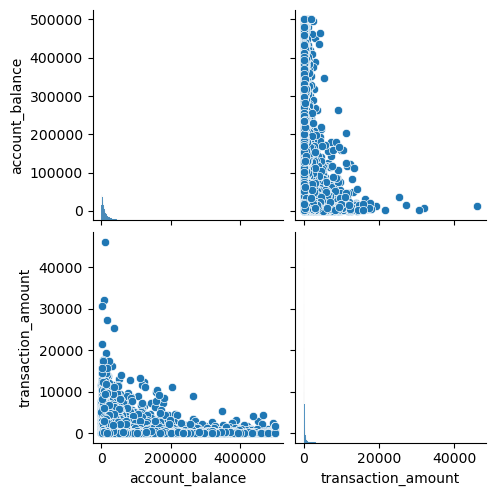

In [232]:
sns.pairplot(num_colum[['account_balance','transaction_amount']])

<Axes: xlabel='transaction_amount', ylabel='is_fraud'>

/home/arman/miniconda3/envs/ml100-day/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


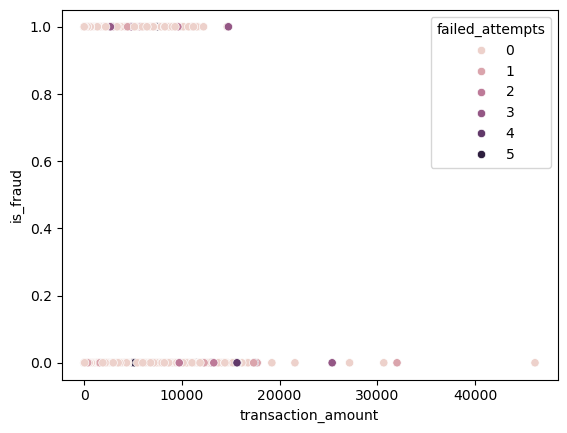

In [233]:
sns.scatterplot(data=num_colum,x=num_colum['transaction_amount'],y=num_colum['is_fraud'],hue='failed_attempts')

<Axes: xlabel='account_balance', ylabel='Count'>

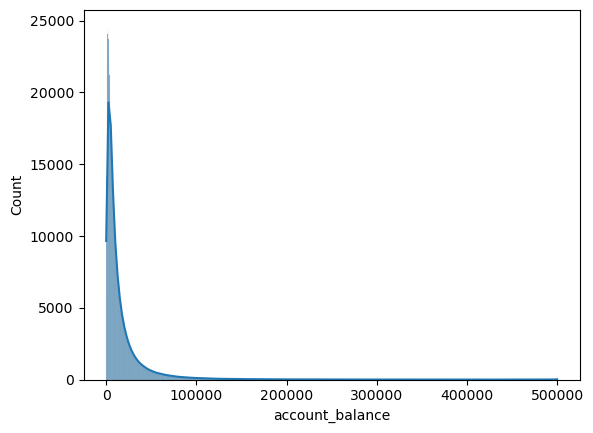

In [234]:
# account_balance data is right skewed 
sns.histplot(df_copy['account_balance'],kde=True)

<Axes: xlabel='transaction_amount', ylabel='Count'>

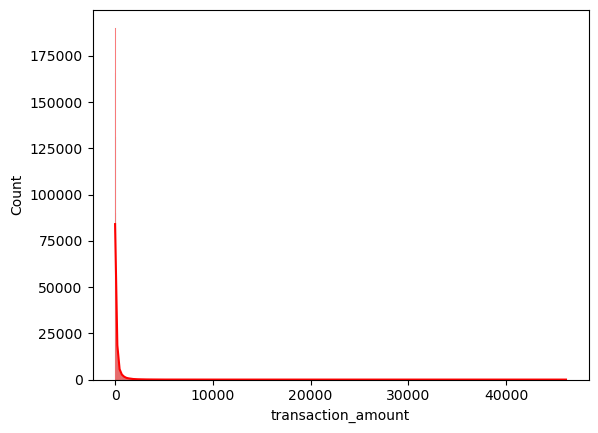

In [235]:
sns.histplot(df_copy['transaction_amount'],kde=True,color='red')

<Axes: xlabel='customer_age', ylabel='Count'>

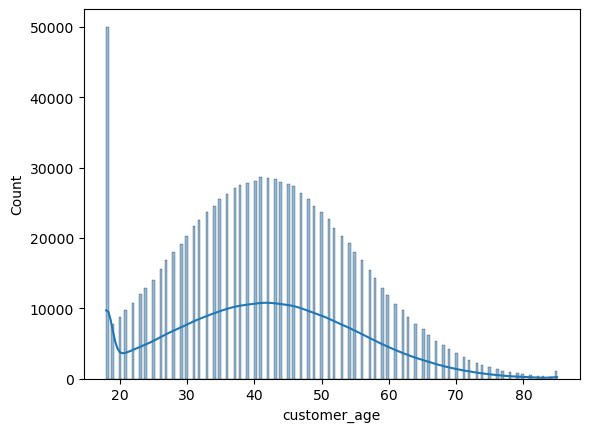

In [236]:
sns.histplot(data=df_copy , x=df_copy['customer_age'],kde=True)

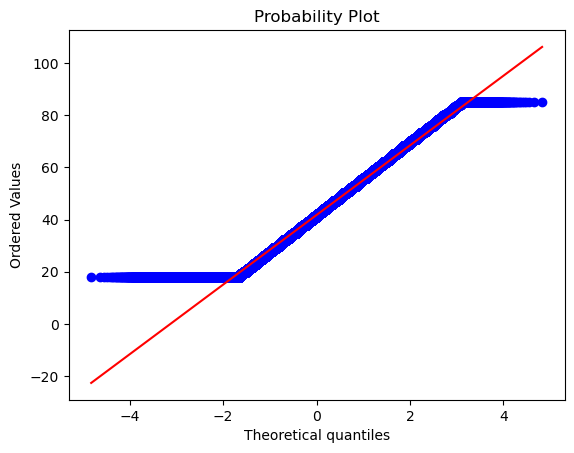

In [237]:
stats.probplot(df_copy['customer_age'],plot=plt)
plt.show()

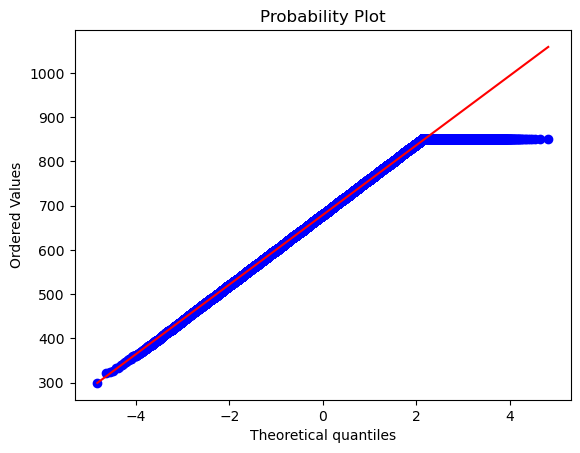

In [238]:
stats.probplot(df_copy['credit_score'],plot=plt)
plt.show()

<Axes: xlabel='credit_score', ylabel='Count'>

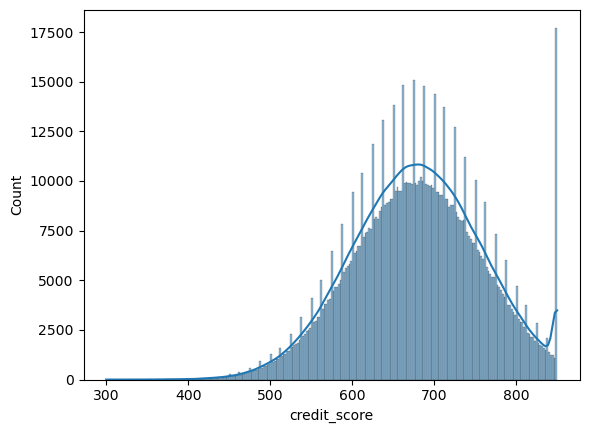

In [239]:
sns.histplot(data=df_copy , x=df_copy['credit_score'],kde=True)


<Axes: xlabel='account_balance', ylabel='Count'>

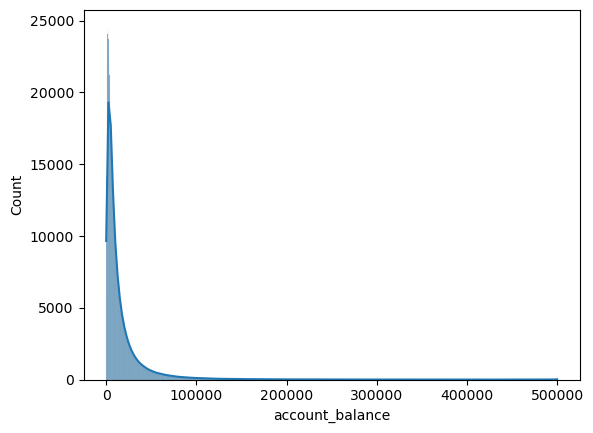

In [240]:
sns.histplot(data=df_copy , x=df_copy['account_balance'],kde=True)


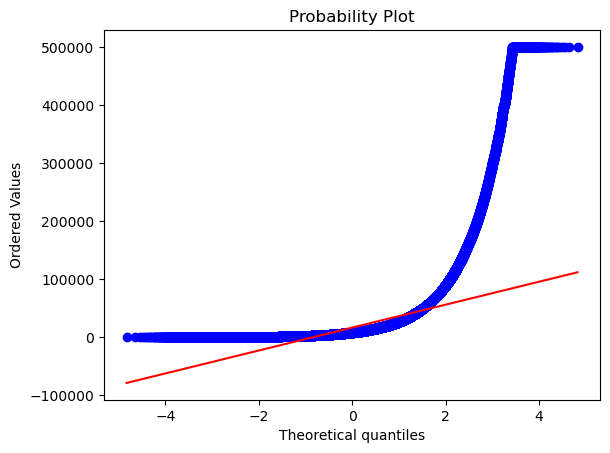

In [241]:
stats.probplot(df_copy['account_balance'],plot=plt)
plt.show()

In [242]:
df_copy.sample(10)

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type,year,month
46687,TXN0000046688,CUST00006694,2022-07-30,2026-07-13 14:12:00,14,1,0,UK,Sydney,Fuel,...,26,6.5,11.98,0,0,0,0,NaN,2022,7
785295,TXN0000785296,CUST00159776,2020-08-05,2026-07-13 01:15:00,1,0,1,Mexico,Mumbai,Education,...,22,73.6,4.61,0,3,0,1,Synthetic Identity,2020,8
459882,TXN0000459883,CUST00055934,2020-01-02,2026-07-13 19:56:00,19,0,0,USA,Toronto,Grocery,...,25,33.0,12.40,0,1,0,0,NaN,2020,1
129032,TXN0000129033,CUST00016513,2023-10-13,2026-07-13 10:23:00,10,0,0,Japan,Lyon,Crypto Exchange,...,18,10.4,12.07,0,0,0,0,NaN,2023,10
85662,TXN0000085663,CUST00077321,2020-05-25,2026-07-13 20:49:00,20,0,0,India,Sydney,Fuel,...,19,7.4,73.07,0,0,0,0,NaN,2020,5
676322,TXN0000676323,CUST00062219,2024-05-27,2026-07-13 16:20:00,16,0,0,Germany,Paris,Grocery,...,23,70.5,2.22,1,0,0,0,NaN,2024,5
610870,TXN0000610871,CUST00027764,2023-10-21,2026-07-13 07:32:00,7,1,0,Japan,Guadalajara,ATM Withdrawal,...,15,35.3,5.98,0,0,0,0,NaN,2023,10
138251,TXN0000138252,CUST00023069,2024-06-10,2026-07-13 17:40:00,17,0,0,India,Lyon,Gaming,...,17,56.4,38.71,0,0,0,0,NaN,2024,6
439471,TXN0000439472,CUST00122024,2021-02-23,2026-07-13 08:52:00,8,0,0,Japan,Manchester,Gaming,...,17,15.6,1.00,1,0,0,0,NaN,2021,2
63544,TXN0000063545,CUST00099848,2020-03-27,2026-07-13 03:08:00,3,0,1,USA,Berlin,Online Shopping,...,24,2.4,4.55,0,0,0,0,NaN,2020,3


In [243]:
df_copy.drop(columns=['transaction_id','customer_id','transaction_time','fraud_type']) # country city

,transaction_date,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,payment_method,device_type,customer_age,...,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,year,month
0,2023-08-17,21,0,0,USA,London,Grocery,Bank Transfer,POS Terminal,18,...,157,23,52.7,10.20,0,0,0,0,2023,8
1,2024-02-06,5,0,1,UK,New York,Healthcare,Cheque,Desktop,30,...,153,23,0.9,12.47,0,0,0,0,2024,2
2,2024-06-28,12,0,0,Canada,Delhi,Grocery,Crypto,Mobile,20,...,161,20,9.2,0.08,0,1,0,0,2024,6
3,2023-03-16,2,0,1,France,Tokyo,Utilities,Debit Card,Mobile,29,...,160,25,14.8,17.94,1,0,1,1,2023,3
4,2024-07-12,12,0,0,Canada,Melbourne,Clothing,Debit Card,Desktop,49,...,134,18,38.9,2.16,0,0,0,0,2024,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,2022-11-18,21,0,0,Mexico,Lyon,Electronics,Mobile Payment,Mobile,82,...,145,20,36.5,1.58,0,0,0,0,2022,11
999996,2021-07-03,22,1,1,Mexico,Tokyo,Online Shopping,Credit Card,Tablet,32,...,154,17,20.0,2.10,0,0,0,0,2021,7
999997,2021-08-12,7,0,0,USA,Manchester,Grocery,Credit Card,Tablet,51,...,148,20,3.4,2.74,0,1,0,0,2021,8
999998,2021-06-07,7,0,0,Japan,São Paulo,Electronics,Credit Card,Mobile,38,...,150,16,63.1,3.71,1,1,0,0,2021,6


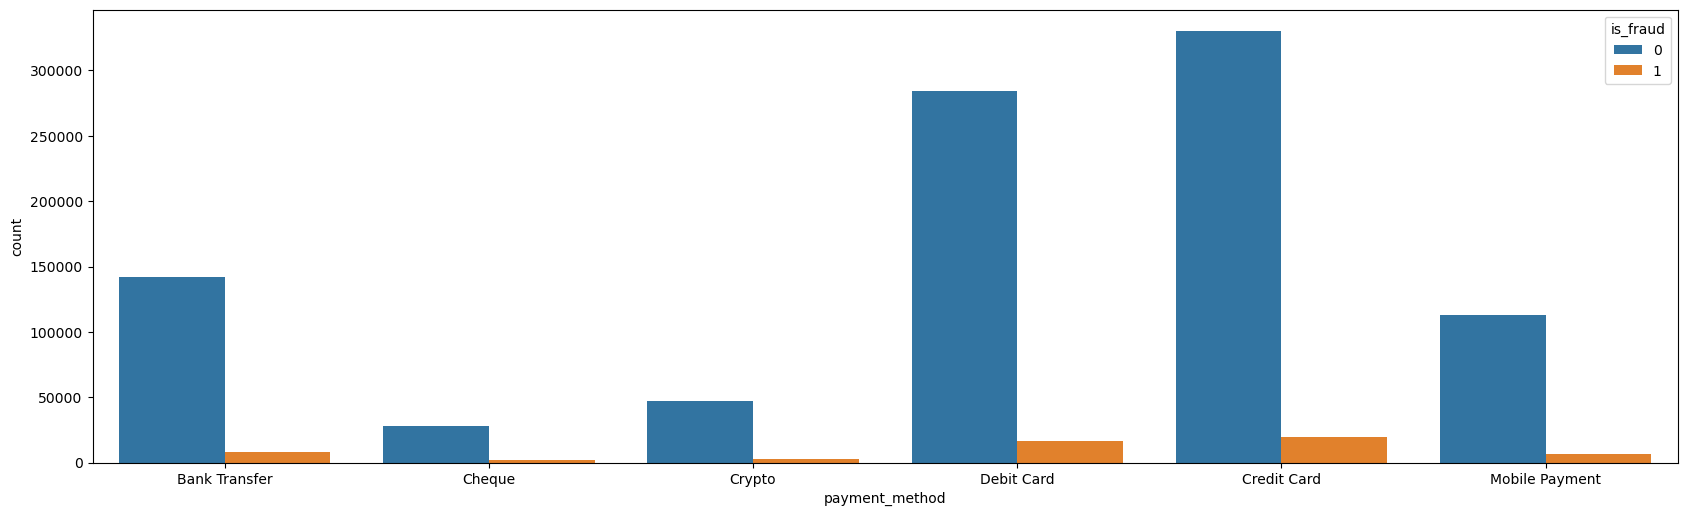

In [244]:
plt.figure(figsize=(45,20))
plt.subplot(3,2,3)
sns.countplot(data=df_copy,x='payment_method',hue='is_fraud')
plt.show()

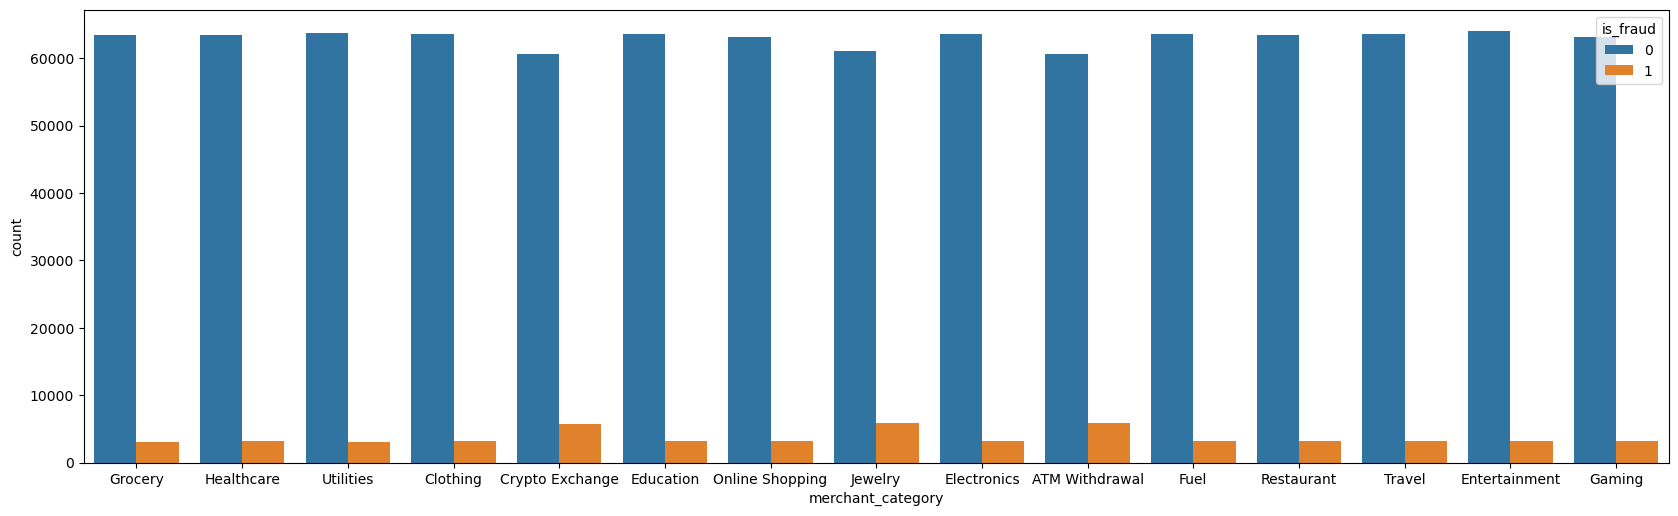

In [245]:
plt.figure(figsize=(45,20))
plt.subplot(3,2,3)
sns.countplot(data=df_copy,x='merchant_category',hue='is_fraud')
plt.show()

In [246]:
df_copy.groupby('hour_of_day')['is_fraud'].sum().sort_values(ascending=False) 

hour_of_day
1     3360
5     3359
6     3345
22    3326
3     3315
4     3303
2     3297
0     3271
23    3263
9     1807
18    1766
8     1764
11    1732
21    1708
20    1687
10    1680
16    1673
17    1672
12    1670
15    1669
19    1667
14    1653
7     1648
13    1620
Name: is_fraud, dtype: int64

In [247]:
df_copy

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type,year,month
0,TXN0000000001,CUST00121959,2023-08-17,2026-07-13 21:13:00,21,0,0,USA,London,Grocery,...,23,52.7,10.20,0,0,0,0,NaN,2023,8
1,TXN0000000002,CUST00146868,2024-02-06,2026-07-13 05:16:00,5,0,1,UK,New York,Healthcare,...,23,0.9,12.47,0,0,0,0,NaN,2024,2
2,TXN0000000003,CUST00131933,2024-06-28,2026-07-13 12:15:00,12,0,0,Canada,Delhi,Grocery,...,20,9.2,0.08,0,1,0,0,NaN,2024,6
3,TXN0000000004,CUST00103695,2023-03-16,2026-07-13 02:53:00,2,0,1,France,Tokyo,Utilities,...,25,14.8,17.94,1,0,1,1,Synthetic Identity,2023,3
4,TXN0000000005,CUST00119880,2024-07-12,2026-07-13 12:39:00,12,0,0,Canada,Melbourne,Clothing,...,18,38.9,2.16,0,0,0,0,NaN,2024,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,TXN0000999996,CUST00176672,2022-11-18,2026-07-13 21:15:00,21,0,0,Mexico,Lyon,Electronics,...,20,36.5,1.58,0,0,0,0,NaN,2022,11
999996,TXN0000999997,CUST00005742,2021-07-03,2026-07-13 22:57:00,22,1,1,Mexico,Tokyo,Online Shopping,...,17,20.0,2.10,0,0,0,0,NaN,2021,7
999997,TXN0000999998,CUST00108137,2021-08-12,2026-07-13 07:37:00,7,0,0,USA,Manchester,Grocery,...,20,3.4,2.74,0,1,0,0,NaN,2021,8
999998,TXN0000999999,CUST00117141,2021-06-07,2026-07-13 07:09:00,7,0,0,Japan,São Paulo,Electronics,...,16,63.1,3.71,1,1,0,0,NaN,2021,6


In [248]:
# which hour is very dangoures for fraud 
hour_fraud = df_copy.groupby(['city','hour_of_day','merchant_category'])['is_fraud'].sum().reset_index().sort_values('is_fraud',ascending=False)
hour_fraud[hour_fraud['city'] == 'Los Angeles']

,city,hour_of_day,merchant_category,is_fraud
1780,Los Angeles,22,Jewelry,24
1465,Los Angeles,1,Jewelry,21
1450,Los Angeles,0,Jewelry,21
1770,Los Angeles,22,ATM Withdrawal,20
1500,Los Angeles,4,ATM Withdrawal,20
...,...,...,...,...
1565,Los Angeles,8,Entertainment,1
1614,Los Angeles,11,Healthcare,1
1648,Los Angeles,13,Travel,1
1732,Los Angeles,19,Gaming,0


In [249]:
df_copy.groupby(['city','merchant_category'])['is_fraud'].sum().reset_index().sort_values('is_fraud',ascending=False)


,city,merchant_category,is_fraud
235,Sydney,Jewelry,354
0,Berlin,ATM Withdrawal,336
220,Rio,Jewelry,318
70,Los Angeles,Jewelry,314
272,Toronto,Crypto Exchange,312
...,...,...,...
52,London,Gaming,134
26,Delhi,Online Shopping,134
173,New York,Grocery,133
125,Mexico City,Entertainment,131


In [250]:
# inbalnace dataset in 0 = 95 % are data and in 1 = only 5 % if i train my model on this data why model going to become biased towords 0
df['is_fraud'].value_counts(normalize=True)

is_fraud
0    0.944745
1    0.055255
Name: proportion, dtype: float64

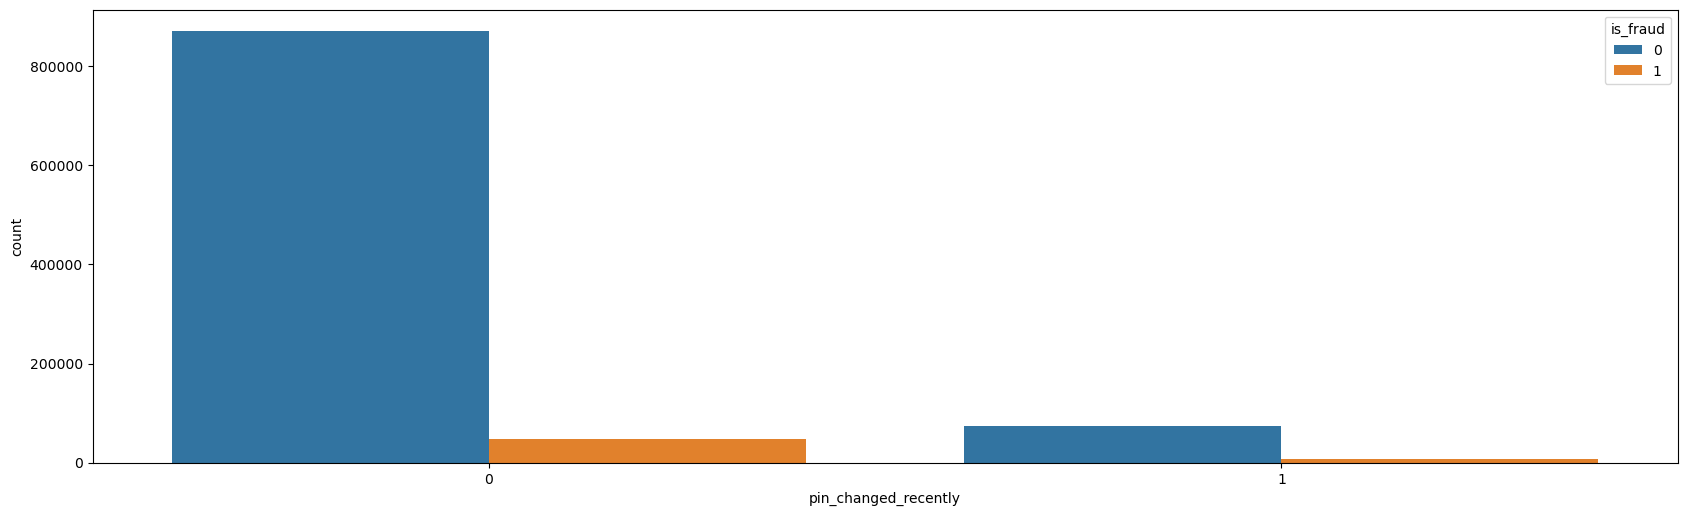

In [251]:
plt.figure(figsize=(45,20))
plt.subplot(3,2,3)
sns.countplot(data=df_copy,x='pin_changed_recently',hue='is_fraud')
plt.show()

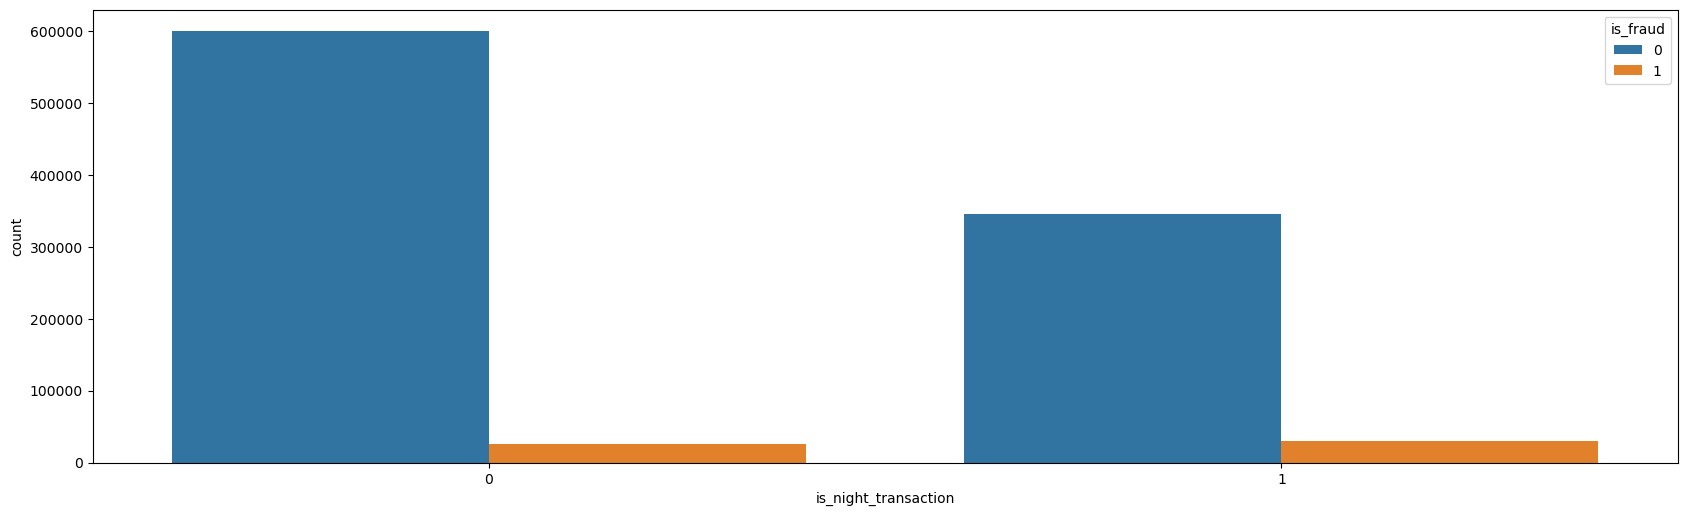

In [252]:
# at night most time fraud happend u can see 
plt.figure(figsize=(45,20))
plt.subplot(3,2,3)
sns.countplot(data=df_copy,x='is_night_transaction',hue='is_fraud')
plt.show()

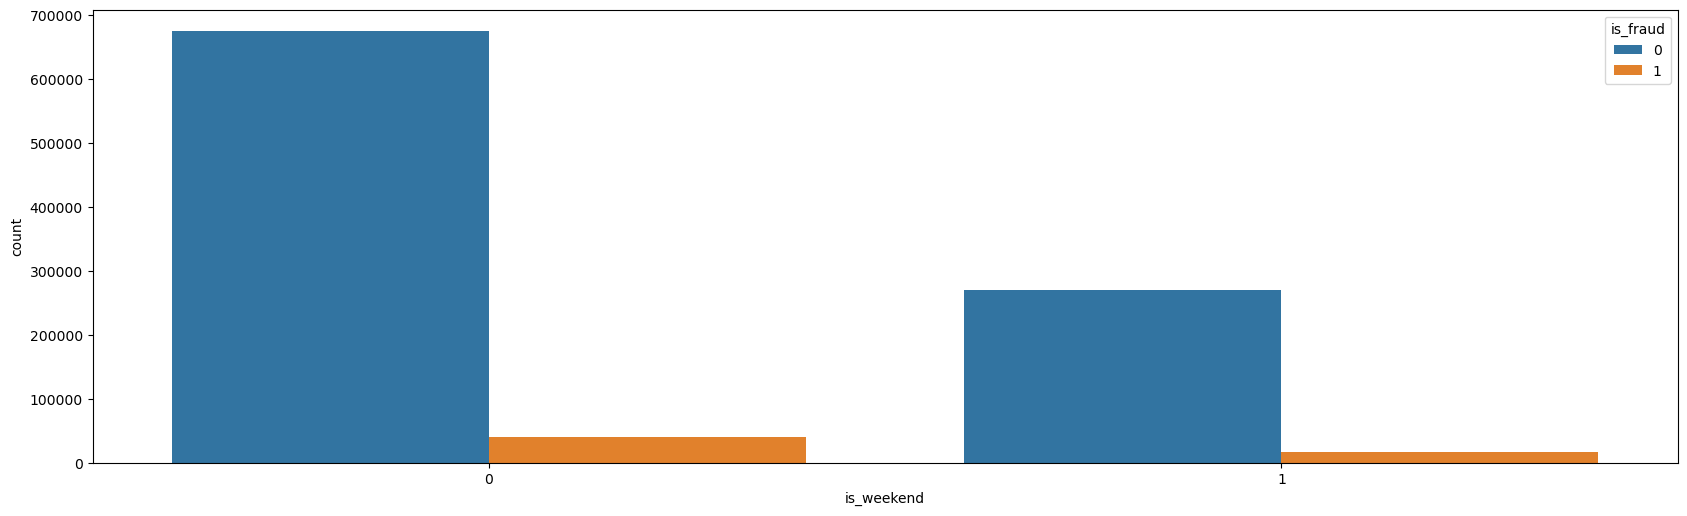

In [253]:
# at night most time fraud happend u can see 
plt.figure(figsize=(45,20))
plt.subplot(3,2,3)
sns.countplot(data=df_copy,x='is_weekend',hue='is_fraud')
plt.show()

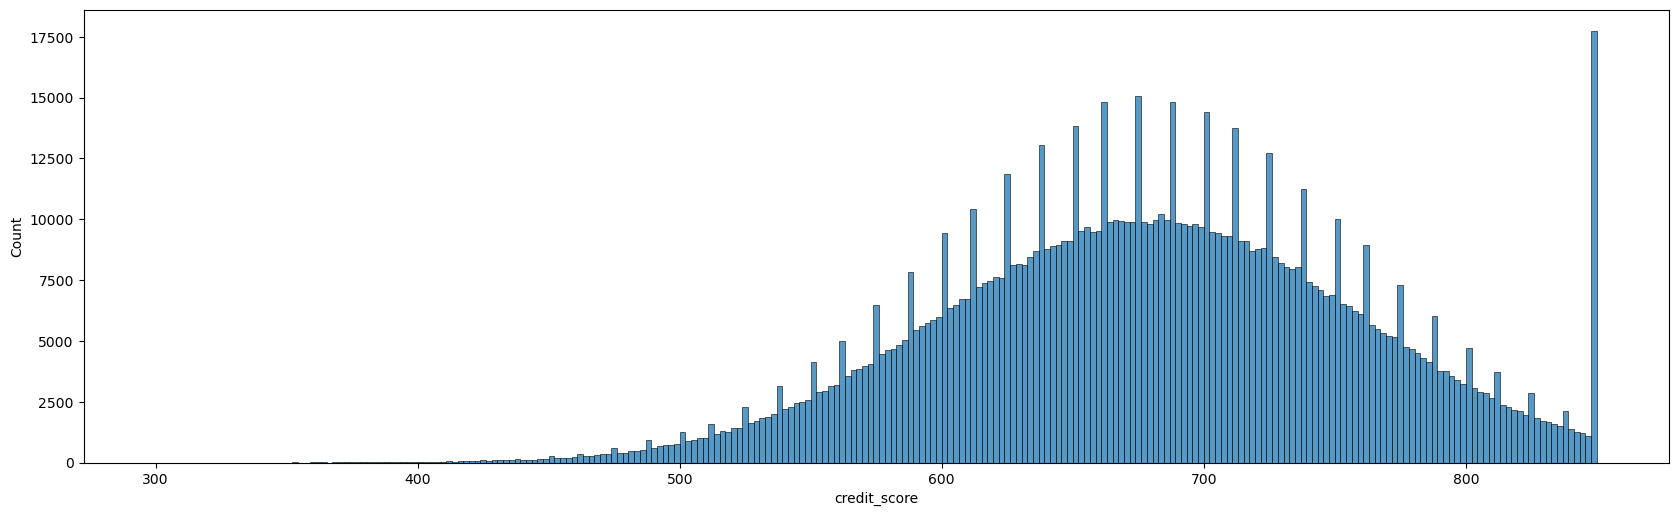

In [254]:
# at night most time fraud happend u can see 
plt.figure(figsize=(45,20))
plt.subplot(3,2,3)
sns.histplot(data=df_copy,x='credit_score')
plt.show()

In [255]:
df_copy['total_transactions'] = df_copy['num_prev_transactions'] + df_copy['transaction_freq_monthly']

In [256]:
df_copy

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type,year,month,total_transactions
0,TXN0000000001,CUST00121959,2023-08-17,2026-07-13 21:13:00,21,0,0,USA,London,Grocery,...,52.7,10.20,0,0,0,0,NaN,2023,8,180
1,TXN0000000002,CUST00146868,2024-02-06,2026-07-13 05:16:00,5,0,1,UK,New York,Healthcare,...,0.9,12.47,0,0,0,0,NaN,2024,2,176
2,TXN0000000003,CUST00131933,2024-06-28,2026-07-13 12:15:00,12,0,0,Canada,Delhi,Grocery,...,9.2,0.08,0,1,0,0,NaN,2024,6,181
3,TXN0000000004,CUST00103695,2023-03-16,2026-07-13 02:53:00,2,0,1,France,Tokyo,Utilities,...,14.8,17.94,1,0,1,1,Synthetic Identity,2023,3,185
4,TXN0000000005,CUST00119880,2024-07-12,2026-07-13 12:39:00,12,0,0,Canada,Melbourne,Clothing,...,38.9,2.16,0,0,0,0,NaN,2024,7,152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,TXN0000999996,CUST00176672,2022-11-18,2026-07-13 21:15:00,21,0,0,Mexico,Lyon,Electronics,...,36.5,1.58,0,0,0,0,NaN,2022,11,165
999996,TXN0000999997,CUST00005742,2021-07-03,2026-07-13 22:57:00,22,1,1,Mexico,Tokyo,Online Shopping,...,20.0,2.10,0,0,0,0,NaN,2021,7,171
999997,TXN0000999998,CUST00108137,2021-08-12,2026-07-13 07:37:00,7,0,0,USA,Manchester,Grocery,...,3.4,2.74,0,1,0,0,NaN,2021,8,168
999998,TXN0000999999,CUST00117141,2021-06-07,2026-07-13 07:09:00,7,0,0,Japan,São Paulo,Electronics,...,63.1,3.71,1,1,0,0,NaN,2021,6,166


In [257]:
df_copy['country'].nunique()

10

In [258]:
df_copy.drop(columns=['transaction_id','customer_id','transaction_date','transaction_time','country','city','fraud_type','transaction_freq_monthly','num_prev_transactions','year','month'],inplace=True)

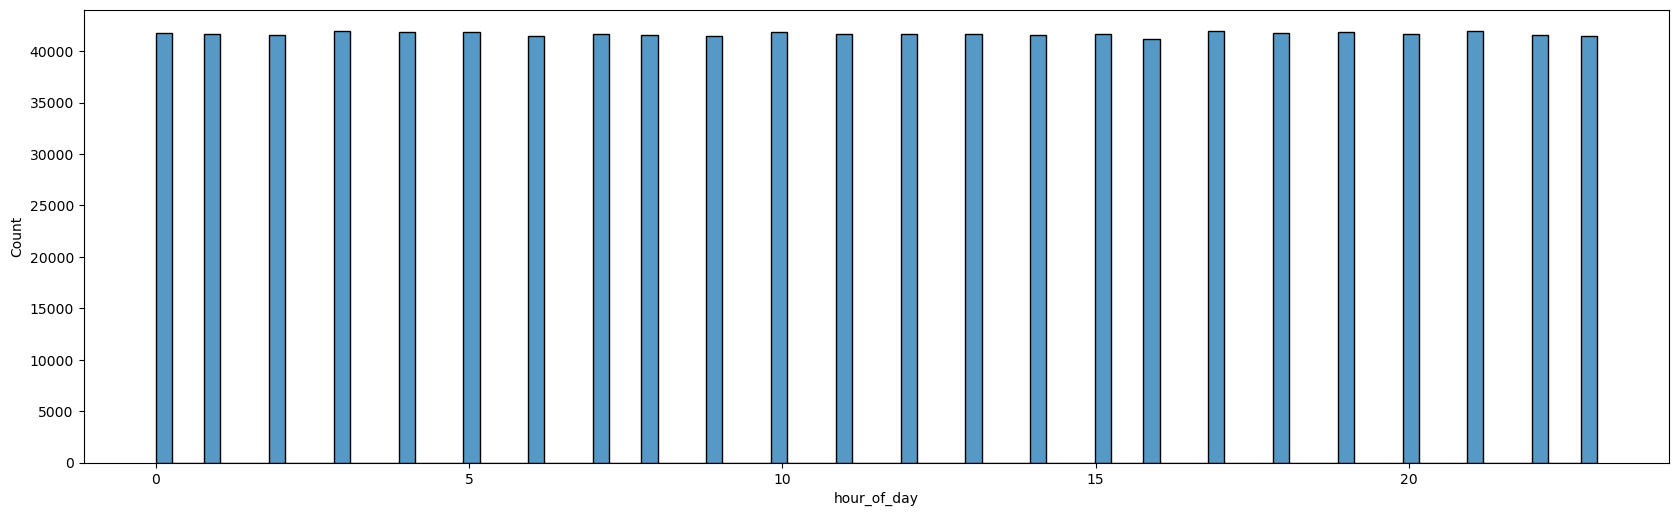

In [259]:
# at night most time fraud happend u can see 
plt.figure(figsize=(45,20))
plt.subplot(3,2,3)
sns.histplot(data=df_copy,x='hour_of_day')
plt.show()

In [260]:
df_copy

,hour_of_day,is_weekend,is_night_transaction,merchant_category,payment_method,device_type,customer_age,credit_score,account_age_years,account_balance,transaction_amount,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,total_transactions
0,21,0,0,Grocery,Bank Transfer,POS Terminal,18,695,7.2,369.36,39.49,52.7,10.20,0,0,0,0,180
1,5,0,1,Healthcare,Cheque,Desktop,30,600,8.6,2681.99,153.71,0.9,12.47,0,0,0,0,176
2,12,0,0,Grocery,Crypto,Mobile,20,711,10.8,44590.64,118.20,9.2,0.08,0,1,0,0,181
3,2,0,1,Utilities,Debit Card,Mobile,29,711,7.3,1213.37,49.50,14.8,17.94,1,0,1,1,185
4,12,0,0,Clothing,Debit Card,Desktop,49,751,11.8,34615.01,30.74,38.9,2.16,0,0,0,0,152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,21,0,0,Electronics,Mobile Payment,Mobile,82,618,8.7,32888.79,1923.52,36.5,1.58,0,0,0,0,165
999996,22,1,1,Online Shopping,Credit Card,Tablet,32,640,8.8,129059.18,146.16,20.0,2.10,0,0,0,0,171
999997,7,0,0,Grocery,Credit Card,Tablet,51,682,1.9,2486.79,27.38,3.4,2.74,0,1,0,0,168
999998,7,0,0,Electronics,Credit Card,Mobile,38,800,2.8,7546.63,365.30,63.1,3.71,1,1,0,0,166


In [261]:
df_copy.duplicated().sum()

np.int64(0)

In [262]:
df_copy.to_csv('csv/bank_fraud_cleaned_data.csv',index=False)

In [263]:
df_copy['device_type'].unique()

array(['POS Terminal', 'Desktop', 'Mobile', 'ATM', 'Tablet'], dtype=object)

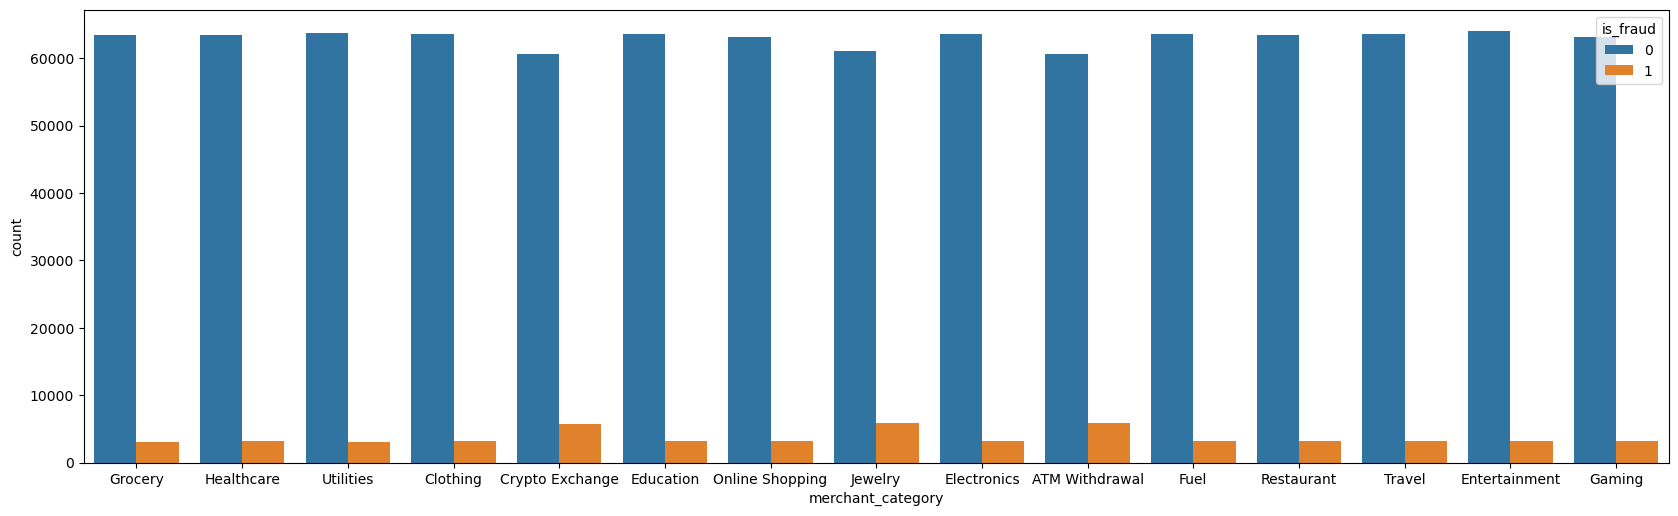

In [264]:
# at night most time fraud happend u can see 
plt.figure(figsize=(45,20))
plt.subplot(3,2,3)
sns.countplot(data=df_copy,x='merchant_category',hue='is_fraud')
plt.show()

In [265]:
numrical_data  = df_copy.select_dtypes(['float','int'])
corr = numrical_data.corr()

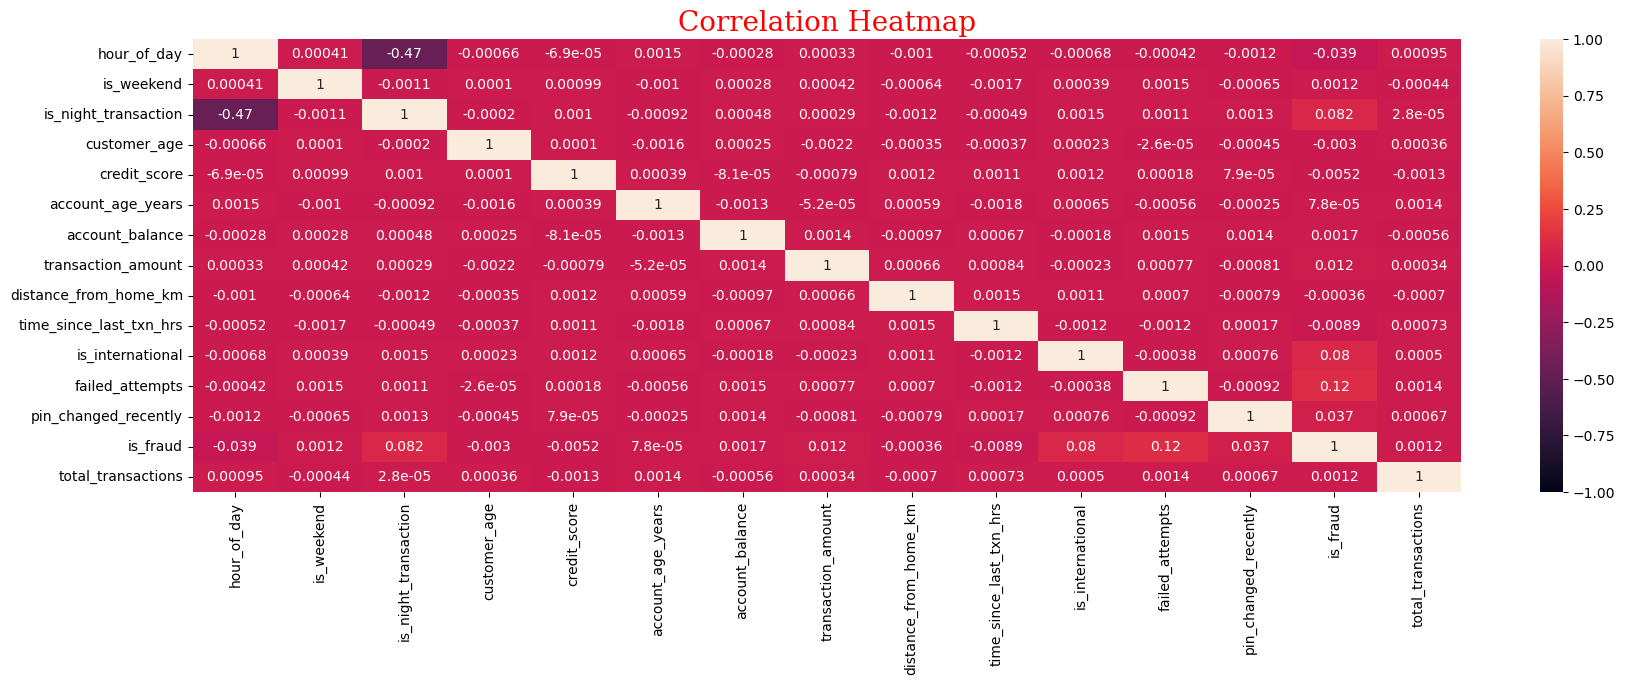

In [266]:

# at night most time fraud happend u can see 
plt.figure(figsize=(45,20))
plt.subplot(3,2,3)
sns.heatmap(corr, vmin=-1, vmax=1, annot=True)
font1 = {'family':'serif','color':'red','size':20}
plt.title('Correlation Heatmap',fontdict=font1)
plt.show()

In [267]:
df_copy

,hour_of_day,is_weekend,is_night_transaction,merchant_category,payment_method,device_type,customer_age,credit_score,account_age_years,account_balance,transaction_amount,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,total_transactions
0,21,0,0,Grocery,Bank Transfer,POS Terminal,18,695,7.2,369.36,39.49,52.7,10.20,0,0,0,0,180
1,5,0,1,Healthcare,Cheque,Desktop,30,600,8.6,2681.99,153.71,0.9,12.47,0,0,0,0,176
2,12,0,0,Grocery,Crypto,Mobile,20,711,10.8,44590.64,118.20,9.2,0.08,0,1,0,0,181
3,2,0,1,Utilities,Debit Card,Mobile,29,711,7.3,1213.37,49.50,14.8,17.94,1,0,1,1,185
4,12,0,0,Clothing,Debit Card,Desktop,49,751,11.8,34615.01,30.74,38.9,2.16,0,0,0,0,152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,21,0,0,Electronics,Mobile Payment,Mobile,82,618,8.7,32888.79,1923.52,36.5,1.58,0,0,0,0,165
999996,22,1,1,Online Shopping,Credit Card,Tablet,32,640,8.8,129059.18,146.16,20.0,2.10,0,0,0,0,171
999997,7,0,0,Grocery,Credit Card,Tablet,51,682,1.9,2486.79,27.38,3.4,2.74,0,1,0,0,168
999998,7,0,0,Electronics,Credit Card,Mobile,38,800,2.8,7546.63,365.30,63.1,3.71,1,1,0,0,166


In [269]:
vif_df = df_copy.copy()

In [270]:
vif_df

,hour_of_day,is_weekend,is_night_transaction,merchant_category,payment_method,device_type,customer_age,credit_score,account_age_years,account_balance,transaction_amount,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,total_transactions
0,21,0,0,Grocery,Bank Transfer,POS Terminal,18,695,7.2,369.36,39.49,52.7,10.20,0,0,0,0,180
1,5,0,1,Healthcare,Cheque,Desktop,30,600,8.6,2681.99,153.71,0.9,12.47,0,0,0,0,176
2,12,0,0,Grocery,Crypto,Mobile,20,711,10.8,44590.64,118.20,9.2,0.08,0,1,0,0,181
3,2,0,1,Utilities,Debit Card,Mobile,29,711,7.3,1213.37,49.50,14.8,17.94,1,0,1,1,185
4,12,0,0,Clothing,Debit Card,Desktop,49,751,11.8,34615.01,30.74,38.9,2.16,0,0,0,0,152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,21,0,0,Electronics,Mobile Payment,Mobile,82,618,8.7,32888.79,1923.52,36.5,1.58,0,0,0,0,165
999996,22,1,1,Online Shopping,Credit Card,Tablet,32,640,8.8,129059.18,146.16,20.0,2.10,0,0,0,0,171
999997,7,0,0,Grocery,Credit Card,Tablet,51,682,1.9,2486.79,27.38,3.4,2.74,0,1,0,0,168
999998,7,0,0,Electronics,Credit Card,Mobile,38,800,2.8,7546.63,365.30,63.1,3.71,1,1,0,0,166


In [271]:
vif_df_num = vif_df.select_dtypes(['int','float'])

In [272]:
cor = vif_df_num.corr()

In [273]:
cor

,hour_of_day,is_weekend,is_night_transaction,customer_age,credit_score,account_age_years,account_balance,transaction_amount,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,total_transactions
hour_of_day,1.000000,0.000412,-0.467811,-0.000663,-0.000069,0.001518,-0.000283,0.000330,-0.001018,-0.000517,-0.000681,-0.000423,-0.001177,-0.039046,0.000951
is_weekend,0.000412,1.000000,-0.001081,0.000103,0.000989,-0.001009,0.000276,0.000423,-0.000644,-0.001720,0.000393,0.001549,-0.000654,0.001190,-0.000442
is_night_transaction,-0.467811,-0.001081,1.000000,-0.000203,0.001028,-0.000918,0.000485,0.000290,-0.001199,-0.000488,0.001456,0.001132,0.001289,0.082405,0.000028
customer_age,-0.000663,0.000103,-0.000203,1.000000,0.000100,-0.001574,0.000246,-0.002210,-0.000354,-0.000373,0.000234,-0.000026,-0.000451,-0.002966,0.000363
credit_score,-0.000069,0.000989,0.001028,0.000100,1.000000,0.000390,-0.000081,-0.000795,0.001248,0.001068,0.001245,0.000184,0.000079,-0.005224,-0.001296
account_age_years,0.001518,-0.001009,-0.000918,-0.001574,0.000390,1.000000,-0.001258,-0.000052,0.000595,-0.001797,0.000648,-0.000556,-0.000245,0.000078,0.001378
account_balance,-0.000283,0.000276,0.000485,0.000246,-0.000081,-0.001258,1.000000,0.001382,-0.000967,0.000666,-0.000183,0.001537,0.001369,0.001696,-0.000557
transaction_amount,0.000330,0.000423,0.000290,-0.002210,-0.000795,-0.000052,0.001382,1.000000,0.000657,0.000843,-0.000228,0.000765,-0.000808,0.012290,0.000339
distance_from_home_km,-0.001018,-0.000644,-0.001199,-0.000354,0.001248,0.000595,-0.000967,0.000657,1.000000,0.001490,0.001053,0.000704,-0.000790,-0.000365,-0.000701
time_since_last_txn_hrs,-0.000517,-0.001720,-0.000488,-0.000373,0.001068,-0.001797,0.000666,0.000843,0.001490,1.000000,-0.001234,-0.001188,0.000167,-0.008909,0.000730


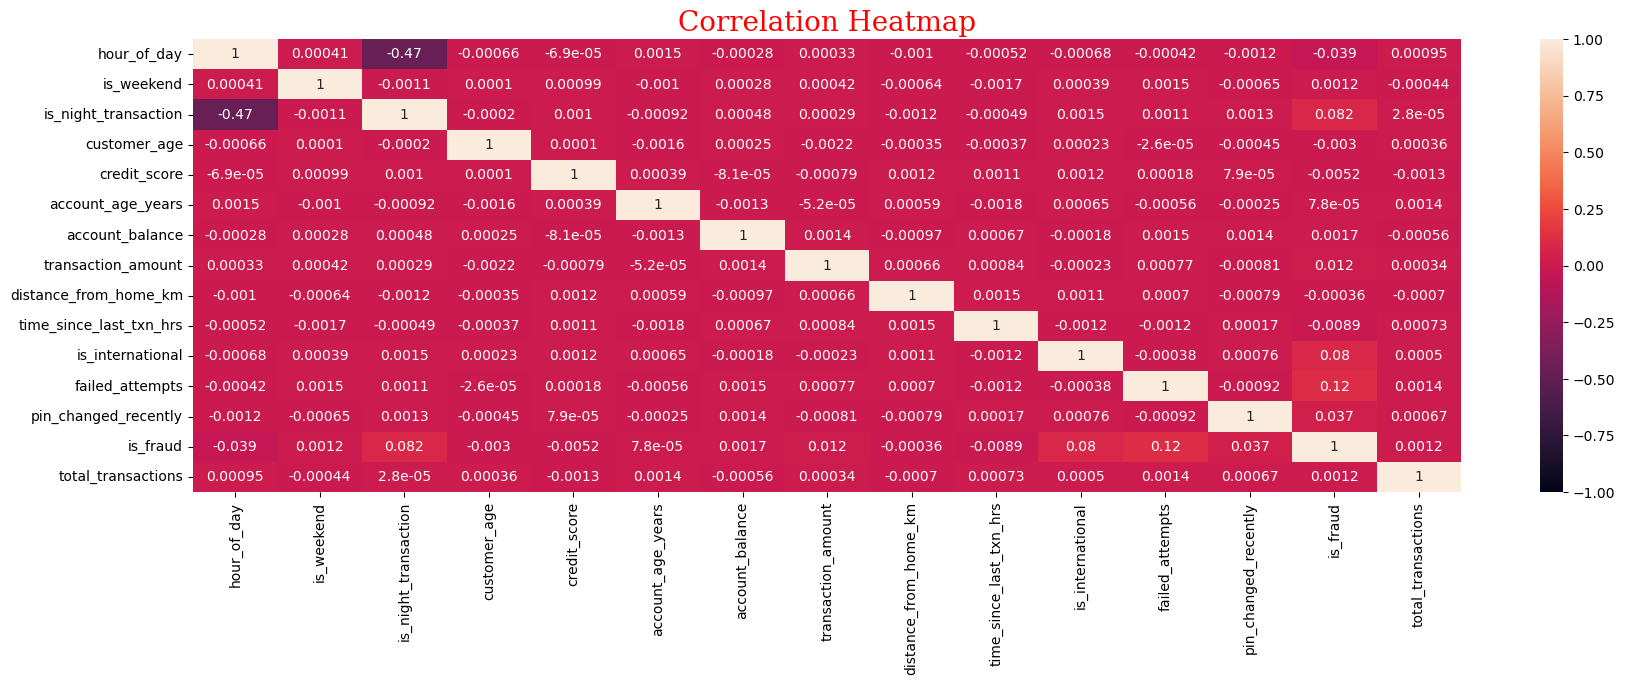

In [ ]:

# at night most time fraud happend u can see 
plt.figure(figsize=(45,20))
plt.subplot(3,2,3)
sns.heatmap(cor, vmin=-1, vmax=1, annot=True)
font1 = {'family':'serif','color':'red','size':20}
plt.title('Correlation Heatmap',fontdict=font1)
plt.show()

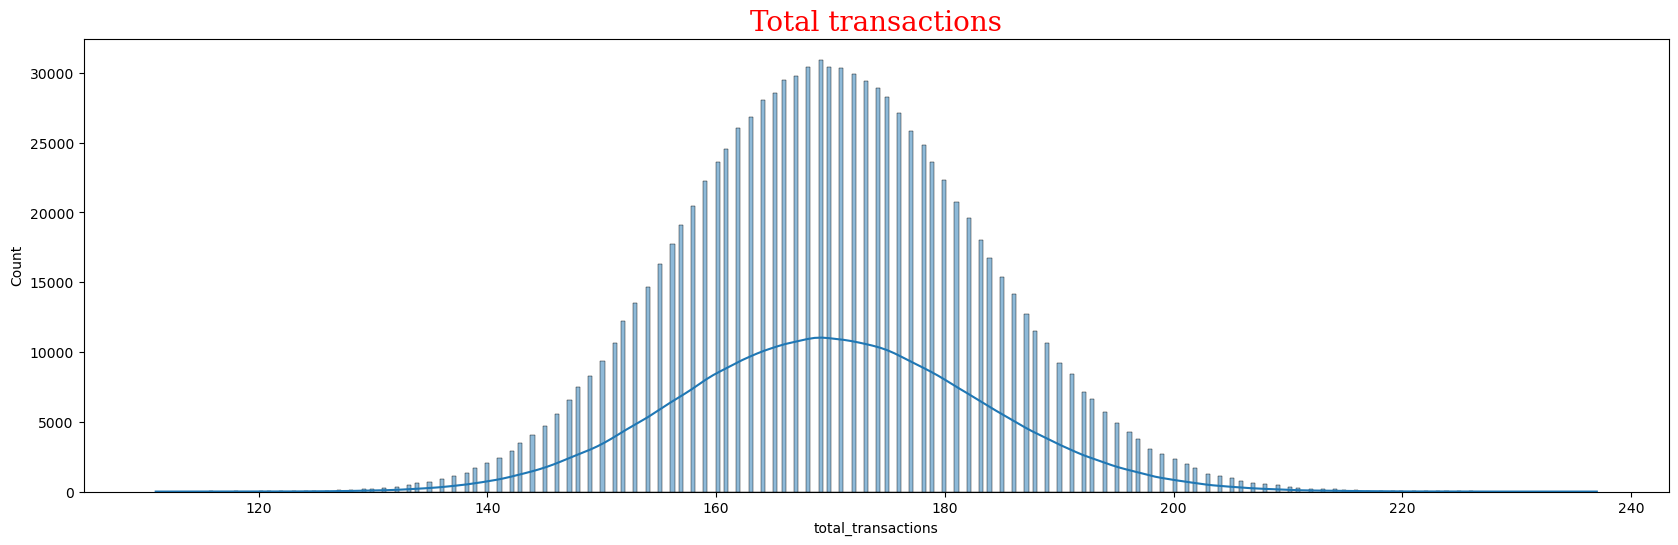

In [274]:

# at night most time fraud happend u can see 
plt.figure(figsize=(45,20))
plt.subplot(3,2,3)
sns.histplot(vif_df['total_transactions'],kde=True)
font1 = {'family':'serif','color':'red','size':20}
plt.title('Total transactions',fontdict=font1)
plt.show()

In [ ]:
vif_df

,hour_of_day,is_weekend,is_night_transaction,merchant_category,payment_method,device_type,customer_age,credit_score,account_age_years,account_balance,transaction_amount,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,total_transactions
0,21,0,0,Grocery,Bank Transfer,POS Terminal,18,695,7.2,369.36,39.49,52.7,10.20,0,0,0,0,180
1,5,0,1,Healthcare,Cheque,Desktop,30,600,8.6,2681.99,153.71,0.9,12.47,0,0,0,0,176
2,12,0,0,Grocery,Crypto,Mobile,20,711,10.8,44590.64,118.20,9.2,0.08,0,1,0,0,181
3,2,0,1,Utilities,Debit Card,Mobile,29,711,7.3,1213.37,49.50,14.8,17.94,1,0,1,1,185
4,12,0,0,Clothing,Debit Card,Desktop,49,751,11.8,34615.01,30.74,38.9,2.16,0,0,0,0,152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,21,0,0,Electronics,Mobile Payment,Mobile,82,618,8.7,32888.79,1923.52,36.5,1.58,0,0,0,0,165
999996,22,1,1,Online Shopping,Credit Card,Tablet,32,640,8.8,129059.18,146.16,20.0,2.10,0,0,0,0,171
999997,7,0,0,Grocery,Credit Card,Tablet,51,682,1.9,2486.79,27.38,3.4,2.74,0,1,0,0,168
999998,7,0,0,Electronics,Credit Card,Mobile,38,800,2.8,7546.63,365.30,63.1,3.71,1,1,0,0,166


In [ ]:
vif_df = pd.get_dummies(vif_df,columns=['merchant_category','payment_method','device_type'],drop_first=True,dtype=int)

In [ ]:
# vif = pd.DataFrame() 
# vif['Feature'] = vif_df.columns
# vif['Vif'] = [variance_inflation_factor(vif_df.values,i) for i in range(vif_df.shape[1])]
# vif

,Feature,Vif
0,hour_of_day,4.725600
1,is_weekend,1.398751
2,is_night_transaction,2.038875
3,customer_age,10.330404
4,credit_score,56.187980
5,account_age_years,2.018553
6,account_balance,1.345404
7,transaction_amount,1.593037
8,distance_from_home_km,1.992964
9,time_since_last_txn_hrs,1.993700


In [ ]:
#  if vif come inf and greater then 10 means your column can be predected by other column means  very high multicollinearity
# new_df = vif.copy()

In [ ]:
# new_df

,Feature,Vif
0,hour_of_day,4.725600
1,is_weekend,1.398751
2,is_night_transaction,2.038875
3,customer_age,10.330404
4,credit_score,56.187980
5,account_age_years,2.018553
6,account_balance,1.345404
7,transaction_amount,1.593037
8,distance_from_home_km,1.992964
9,time_since_last_txn_hrs,1.993700
